In [1]:
import pandas as pd

In [2]:
df_clean = pd.read_csv('data/processed/ai4i2020_clean.csv') 

In [3]:
df_clean

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,soma_subtipos
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9968,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,0
9969,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,0
9970,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,0
9971,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,0


In [4]:
taxa_falha = df_clean['Machine failure'].mean() * 100
print(f"Taxa de falha: {taxa_falha:.2f}%")

Taxa de falha: 3.31%


In [5]:
falha_por_tipo = df_clean.groupby('Type')['Machine failure'].agg(['count', 'sum', 'mean'])
falha_por_tipo['mean'] = falha_por_tipo['mean'] * 100
falha_por_tipo

,count,sum,mean
Type,,,
H,998,20,2.004008
L,5984,231,3.860294
M,2991,79,2.641257


In [6]:
df_clean['Tool wear [min]'].describe()

count    9973.000000
mean      107.921087
std        63.649152
min         0.000000
25%        53.000000
50%       108.000000
75%       162.000000
max       253.000000
Name: Tool wear [min], dtype: float64

In [7]:
bins = [0, 50, 100, 150, 200, 253]
labels = ['0-50', '51-100', '101-150', '151-200', '201-253']

df_clean['faixa_desgaste'] = pd.cut(df_clean['Tool wear [min]'], bins=bins, labels=labels, include_lowest=True)

In [8]:
falha_por_desgaste = df_clean.groupby('faixa_desgaste')['Machine failure'].agg(['count', 'sum', 'mean'])
falha_por_desgaste['mean'] = falha_por_desgaste['mean'] * 100
falha_por_desgaste

,count,sum,mean
faixa_desgaste,,,
0-50,2390,50,2.092050
51-100,2267,52,2.293780
101-150,2289,47,2.053298
151-200,2267,64,2.823114
201-253,760,117,15.394737


In [9]:
df_clean['Torque [Nm]'].describe()

count    9973.000000
mean       39.978993
std         9.966805
min         3.800000
25%        33.200000
50%        40.100000
75%        46.700000
max        76.600000
Name: Torque [Nm], dtype: float64

In [10]:
bins = [0, 30, 45, 55, 65, 76.6]
labels = ['0-30', '31-45', '46-55', '56-65', '66-76.6']

df_clean['faixa_torque'] = pd.cut(df_clean['Torque [Nm]'], bins=bins, labels=labels, include_lowest=True)

In [11]:
falha_por_torque = df_clean.groupby('faixa_torque')['Machine failure'].agg(['count', 'sum', 'mean'])
falha_por_torque['mean'] = falha_por_torque['mean'] * 100
falha_por_torque

,count,sum,mean
faixa_torque,,,
0-30,1597,40,2.504696
31-45,5288,31,0.586233
46-55,2483,111,4.470399
56-65,540,94,17.407407
66-76.6,65,54,83.076923


In [12]:
df_clean['Rotational speed [rpm]'].describe()

count    9973.000000
mean     1538.893212
std       179.412171
min      1168.000000
25%      1423.000000
50%      1503.000000
75%      1612.000000
max      2886.000000
Name: Rotational speed [rpm], dtype: float64

In [13]:
bins_rotacao = [0, 1100, 1300, 1500, 1600, 2886]
labels_rotacao = ['0-1100', '1101-1300', '1301-1500', '1501-1600', '1601-2886']

df_clean['faixa_rotacao'] = pd.cut(df_clean['Rotational speed [rpm]'], bins=bins_rotacao, labels=labels_rotacao, include_lowest=True)

In [14]:
df_clean['Rotational speed [rpm]'].dtype

dtype('int64')

In [15]:
falha_por_rotacao = df_clean.groupby('faixa_rotacao')['Machine failure'].agg(['count', 'sum', 'mean'])
falha_por_rotacao['mean'] = falha_por_rotacao['mean'] * 100
falha_por_rotacao

,count,sum,mean
faixa_rotacao,,,
1101-1300,216,49,22.685185
1301-1500,4694,223,4.750746
1501-1600,2357,12,0.509122
1601-2886,2706,46,1.699926


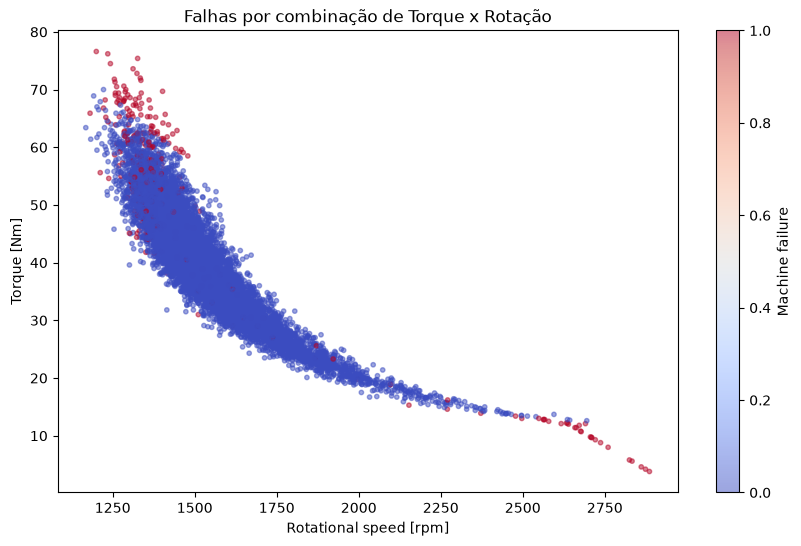

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df_clean['Rotational speed [rpm]'], df_clean['Torque [Nm]'], 
            c=df_clean['Machine failure'], cmap='coolwarm', alpha=0.5, s=10)
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.title('Falhas por combinação de Torque x Rotação')
plt.colorbar(label='Machine failure')
plt.show()

In [17]:
df_clean[['Air temperature [K]', 'Process temperature [K]']].describe()

,Air temperature [K],Process temperature [K]
count,9973.000000,9973.000000
mean,300.003259,310.004031
std,2.000548,1.483692
min,295.300000,305.700000
25%,298.300000,308.800000
50%,300.100000,310.100000
75%,301.500000,311.100000
max,304.500000,313.800000


In [18]:
df_clean['diff_temperatura'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']
df_clean['diff_temperatura'].describe()

count    9973.000000
mean       10.000772
std         1.001423
min         7.600000
25%         9.300000
50%         9.800000
75%        11.000000
max        12.100000
Name: diff_temperatura, dtype: float64

In [19]:
bins_diff = [7.6, 9, 9.5, 10, 10.5, 11, 12.1]
labels_diff = ['7.6-9', '9-9.5', '9.5-10', '10-10.5', '10.5-11', '11-12.1']
df_clean['faixa_diff_temp'] = pd.cut(df_clean['diff_temperatura'], bins=bins_diff, labels=labels_diff, include_lowest=True)

In [20]:
bins_air = [295, 298, 300, 302, 304.5]
labels_air = ['295-298', '298-300', '300-302', '302-304.5']
df_clean['faixa_air_temp'] = pd.cut(df_clean['Air temperature [K]'], bins=bins_air, labels=labels_air, include_lowest=True)

bins_process = [305, 309, 310, 311, 314]
labels_process = ['305-309', '309-310', '310-311', '311-314']
df_clean['faixa_process_temp'] = pd.cut(df_clean['Process temperature [K]'], bins=bins_process, labels=labels_process, include_lowest=True)

In [21]:
falha_por_air = df_clean.groupby('faixa_air_temp')['Machine failure'].agg(['count', 'sum', 'mean'])
falha_por_air['mean'] = falha_por_air['mean'] * 100

falha_por_process = df_clean.groupby('faixa_process_temp')['Machine failure'].agg(['count', 'sum', 'mean'])
falha_por_process['mean'] = falha_por_process['mean'] * 100

falha_por_diff = df_clean.groupby('faixa_diff_temp')['Machine failure'].agg(['count', 'sum', 'mean'])
falha_por_diff['mean'] = falha_por_diff['mean'] * 100

In [22]:
falha_por_air

,count,sum,mean
faixa_air_temp,,,
295-298,1945,42,2.159383
298-300,2999,63,2.100700
300-302,3168,96,3.030303
302-304.5,1861,129,6.931757


In [23]:
falha_por_process

,count,sum,mean
faixa_process_temp,,,
305-309,2920,68,2.328767
309-310,2032,43,2.116142
310-311,2514,126,5.011933
311-314,2507,93,3.709613


In [24]:
falha_por_diff

,count,sum,mean
faixa_diff_temp,,,
7.6-9,1738,148,8.515535
9-9.5,2151,48,2.231520
9.5-10,1624,32,1.970443
10-10.5,771,21,2.723735
10.5-11,1546,35,2.263907
11-12.1,2134,44,2.061856


In [25]:
df_clean.to_csv('data/processed/ai4i2020_eda.csv', index=False)

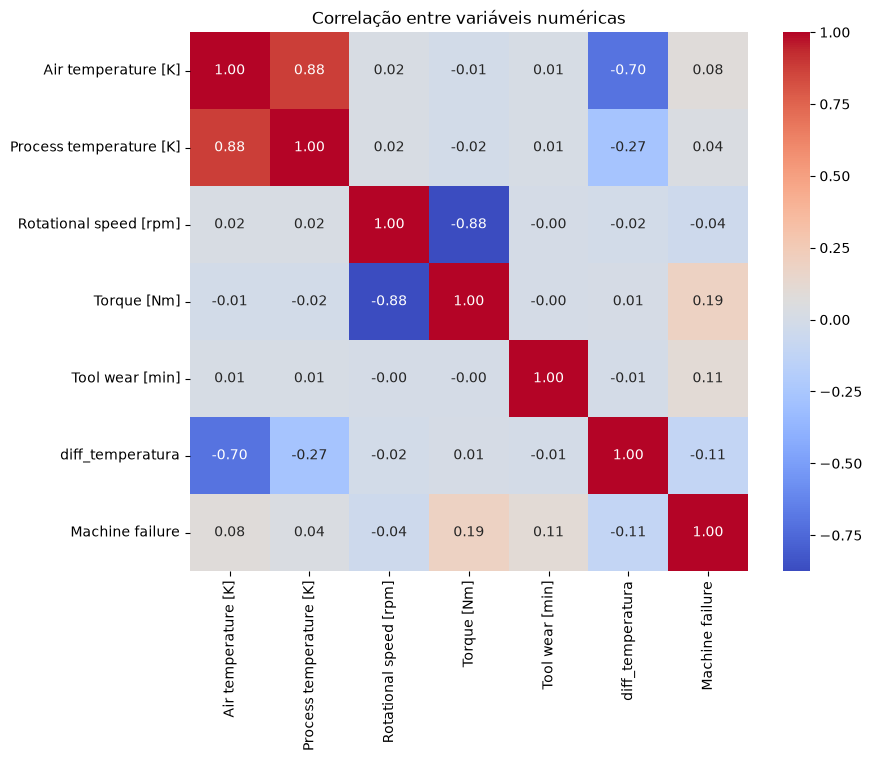

In [26]:
import seaborn as sns

num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 
            'Torque [Nm]', 'Tool wear [min]', 'diff_temperatura', 'Machine failure']

plt.figure(figsize=(9,7))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.show()

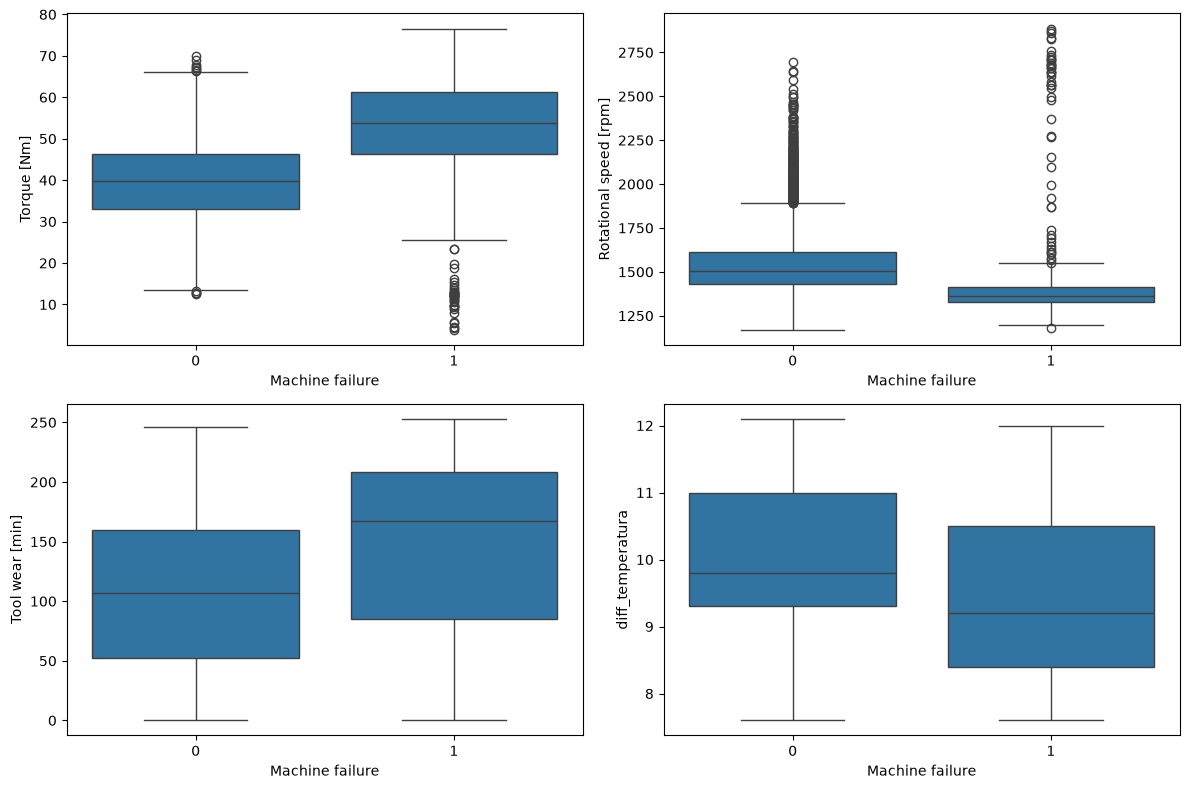

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.boxplot(data=df_clean, x='Machine failure', y='Torque [Nm]', ax=axes[0,0])
sns.boxplot(data=df_clean, x='Machine failure', y='Rotational speed [rpm]', ax=axes[0,1])
sns.boxplot(data=df_clean, x='Machine failure', y='Tool wear [min]', ax=axes[1,0])
sns.boxplot(data=df_clean, x='Machine failure', y='diff_temperatura', ax=axes[1,1])

plt.tight_layout()
plt.show()

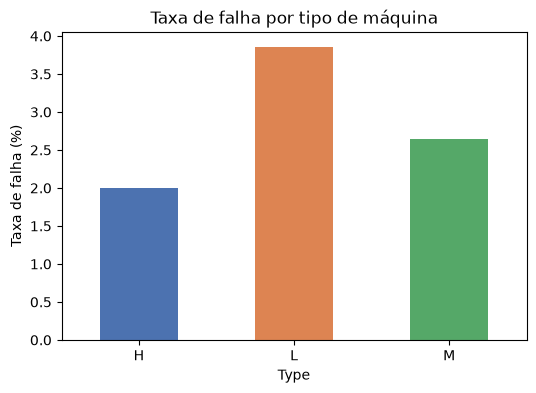

In [28]:
falha_por_tipo_plot = df_clean.groupby('Type')['Machine failure'].mean() * 100

plt.figure(figsize=(6,4))
falha_por_tipo_plot.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.ylabel('Taxa de falha (%)')
plt.title('Taxa de falha por tipo de máquina')
plt.xticks(rotation=0)
plt.show()